# Description of the dataset: Diabetes-MIMIC IV

The dataset used in this study is a subset of the MIMIC-IV (Medical Information Mart for Intensive Care), a large deidentified dataset of patients admitted to Beth  Israel Deaconess Medical Center in Boston between 2008 - 2022. The subset focusses on patients with diabetic diagnoses. The criteria for selecting the subjects were the following:
- Patients diagnosed with diabetes ketoacidosis.
- Subjects aged < 18 years old were excluded.
- Data from each patient’s first ICU admission

These criterias were included tring to replicate the dataset used in the paper "Machine learning prediction models and nomogram to predict the risk ofin-hospital death for severe DKA: A clinical study based on MIMIC-IV, eICUdatabases, and a college hospital ICU" (https://www.sciencedirect.com/science/article/pii/S1386505623000679), with some modifications.

The features included are: 
Demographic: 
- race 
- sex
- age
- weight
- admission emergency 
- insurance

Comorbidities: 
- acute kidney injury
- chronic kidney disease
- diabetes (chronic complication or without)
- cardiac disease
- hypertension
- chronic obstructive pulmonary disease

Laboratory results from the first ICU stay and 24h before and after it, the initial values, the lowest and highest levels of:
- blood PH
- calcium
- creatinine
- hemoglobin
- WBC (white blood cells)
- lactate
- platelets
- potassium
- sodium
- glucose
- chloride
- plasma osmolality (2*sodium + glucose + blood urea nitrogen)
- BUN (blood urea nitrogen)

- Anion gap
- Bicarbonate
- C-Reactive protein -> discarted hight missing values rate
- Albumin -> discarted hight missing values rate

Vital signs in the ICU:
- highest and initial values levels of heart rate
- MAP (mean arterial pressure) -> hight missing values rate
- respiratory rate
- first-day urineoutput

Medicine scores: 
- APS III score
- SOFA score
- GCS score (first gcs total)
- CNS score
- Renal score

Interventions in medicine:
- ventilation
- nitrate pune (nitroprusside ?)
- vasopressor-> (noradrenaline, phenylephrine, epinephrine, dopamine, and dobutamine)
- albumin


## Data set simplified



In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/maria/OneDrive - Maastricht University/Maria Diez Perez/datasets/icu_dka_dataset_simplify.csv")

## Dataset Structure and Size

The dataset contains 1571 entries, representing laboratory test results for unique patients with diabetic dka diagnosis in their first icu admission. The data includes 85 columns with a mix of categorical and numerical variables.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809 entries, 0 to 1808
Data columns (total 77 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   race                 1809 non-null   object 
 1   gender               1809 non-null   object 
 2   age                  1809 non-null   int64  
 3   weight               1783 non-null   float64
 4   emergency            1809 non-null   int64  
 5   insurance            1770 non-null   object 
 6   los                  1809 non-null   float64
 7   aki                  1809 non-null   int64  
 8   ckd                  1809 non-null   int64  
 9   diabetes_with_cc     1809 non-null   int64  
 10  diabetes_without_cc  1809 non-null   int64  
 11  cardiac_disease      1809 non-null   int64  
 12  hypertension         1809 non-null   int64  
 13  copd                 1809 non-null   int64  
 14  ph_initial           1513 non-null   float64
 15  ph_min               1513 non-null   f

In [4]:
df.describe(include='all')

,race,gender,age,weight,emergency,insurance,los,aki,ckd,diabetes_with_cc,...,urineoutput,apsiii,gcs,cns,renal,ventilation,nitroprusside,vasopressor,albumin,in_hospital_death
count,1809,1809,1809.000000,1783.000000,1809.000000,1770,1809.000000,1809.000000,1809.000000,1809.000000,...,1708.000000,1809.000000,1806.000000,1807.000000,1808.000000,1809.000000,1809.000000,1809.000000,1809.000000,1809.000000
unique,6,2,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,White,F,NaN,NaN,NaN,Medicare,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,973,912,NaN,NaN,NaN,654,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,50.459370,77.009703,0.993919,NaN,2.664166,0.532891,0.278607,0.489773,...,2178.104508,47.511885,14.533776,0.518539,1.342367,0.124931,0.001658,0.126589,0.024323,0.054174
std,NaN,NaN,17.913868,21.178306,0.077763,NaN,3.927246,0.499055,0.448438,0.500034,...,1590.231907,18.892306,1.445873,0.850096,1.318859,0.330732,0.040701,0.332604,0.154092,0.226422
min,NaN,NaN,18.000000,7.000000,0.000000,NaN,0.002269,0.000000,0.000000,0.000000,...,0.000000,13.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,36.000000,63.000000,1.000000,NaN,1.058773,0.000000,0.000000,0.000000,...,1043.000000,35.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,51.000000,73.000000,1.000000,NaN,1.730012,1.000000,0.000000,0.000000,...,1850.000000,45.000000,15.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,64.000000,87.000000,1.000000,NaN,2.736713,1.000000,1.000000,1.000000,...,2900.000000,55.000000,15.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
# Check how many categorical, continuous, and binary features we have
categorical_features = []
continuous_features = []
binary_features = []
for column in df.columns:
    series = df[column]
    dtype = series.dtype

    
    # Binary: int and only 2 unique values
    if pd.api.types.is_integer_dtype(dtype) and series.nunique() == 2:
        binary_features.append(column)
    elif pd.api.types.is_object_dtype(dtype):
        categorical_features.append(column)
    elif pd.api.types.is_numeric_dtype(dtype):
        continuous_features.append(column)
    

print(f"Categorical features: {categorical_features}: {len(categorical_features)}")
print(f"Continuous features: {continuous_features}: {len(continuous_features)}")
print(f"Binary features: {binary_features}: {len(binary_features)}")
print(f"Total features: {len(categorical_features) + len(continuous_features) + len(binary_features)}")

Categorical features: ['race', 'gender', 'insurance']: 3
Continuous features: ['age', 'weight', 'los', 'ph_initial', 'ph_min', 'ph_max', 'calcium_initial', 'calcium_min', 'calcium_max', 'creatinine_initial', 'creatinine_min', 'creatinine_max', 'hemoglobin_initial', 'hemoglobin_min', 'hemoglobin_max', 'wbc_initial', 'wbc_min', 'wbc_max', 'lactate_initial', 'lactate_min', 'lactate_max', 'platelet_initial', 'platelet_min', 'platelet_max', 'potassium_initial', 'potassium_min', 'potassium_max', 'sodium_initial', 'sodium_min', 'sodium_max', 'glucose_initial', 'glucose_min', 'glucose_max', 'chloride_initial', 'chloride_min', 'chloride_max', 'bun_initial', 'bun_min', 'bun_max', 'osmolality_initial', 'osmolality_min', 'osmolality_max', 'anion_gap_initial', 'anion_gap_min', 'anion_gap_max', 'bicarbonate_initial', 'bicarbonate_min', 'bicarbonate_max', 'heart_rate_initial', 'heart_rate_max', 'mbp_initial', 'mbp_max', 'mbp_min', 'temperature_max', 'resp_rate_initial', 'resp_rate_max', 'urineoutput'

### Missing Values
The missing values of enrolled individuals in MIMIC-IV were all filled with multiple imputations by chained equations (MICE) before the data splitting, separately.



In [6]:
def get_missing_values(data, missing_percentage=0):
    pc_missing = data.isnull().mean() * 100
    pc_missing = pc_missing[pc_missing > missing_percentage].sort_values(ascending=False)
    num_missing = data.isnull().sum()
    num_missing = num_missing[num_missing > (missing_percentage/100)*len(data)].sort_values(ascending=False)
    return pd.DataFrame({'Percentage Missing': pc_missing, 'Number Missing': num_missing})


In [8]:
# Missing values
print("Missing values:\n", get_missing_values(df))

Missing values:
                      Percentage Missing  Number Missing
lactate_initial               22.609176             409
lactate_max                   22.609176             409
lactate_min                   22.609176             409
ph_initial                    16.362631             296
ph_min                        16.362631             296
ph_max                        16.362631             296
urineoutput                    5.583195             101
insurance                      2.155887              39
weight                         1.437258              26
hemoglobin_initial             1.381979              25
hemoglobin_min                 1.381979              25
hemoglobin_max                 1.381979              25
wbc_initial                    1.326700              24
wbc_min                        1.326700              24
wbc_max                        1.326700              24
platelet_min                   1.271421              23
platelet_initial               

## Plots and graphs

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

In [11]:
def create_missingness_summary(df, feature ='los'):
    los_summary = []
    missing_percent = df.isna().mean()

    for column in df.columns:
        if column != feature and missing_percent[column] > 0.15:
            avg_los_missing = df[df[column].isna()][feature].mean()
            avg_los_present = df[df[column].notna()][feature].mean()
            
            los_summary.append({
                'feature': column,
                'avg_los': avg_los_missing,
                'is_missing': 'Missing'
            })
            los_summary.append({
                'feature': column,
                'avg_los': avg_los_present,
                'is_missing': 'Present'
            })
    
    return pd.DataFrame(los_summary)



In [12]:
def create_missingness_summary_binary(df, feature='in_hospital_death'):
    rows = []
    missing_percent = df.isna().mean()

    for column in df.columns:
        if column == feature:
            continue
        if missing_percent[column] <= 0.15:
            continue

        missing = df[column].isna()

        # counts by class
        count_missing_1 = ((df[feature] == 1) & missing).sum()
        count_missing_0 = ((df[feature] == 0) & missing).sum()

        total_1 = (df[feature] == 1).sum()
        total_0 = (df[feature] == 0).sum()

        # % of missing within each class
        pct_missing_1 = count_missing_1 / total_1 if total_1 else 0.0
        pct_missing_0 = count_missing_0 / total_0 if total_0 else 0.0

        rows.append({
            'feature': column,
            'missing_count_1': int(count_missing_1),
            'missing_pct_1': pct_missing_1,
            'missing_count_0': int(count_missing_0),
            'missing_pct_0': pct_missing_0,
        })

    return pd.DataFrame(rows)


In [13]:
def plot_los_missingness(df_los_summary):
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_los_summary,
        x="feature",
        y="avg",
        hue="is_missing",
        palette={"Missing": "tomato", "Present": "seagreen"}
    )
    plt.xticks(rotation=45)
    plt.ylabel("Average ICU Length of Stay (days)")
    plt.title("ICU Length of Stay vs Missingness of Features (>15% Missing)")
    plt.tight_layout()
    plt.show()

In [14]:
def plot_missingness_summary_binary(summary_df):
    # long form for plotting
    plot_df = summary_df.melt(
        id_vars=['feature'],
        value_vars=['missing_pct_1', 'missing_pct_0'],
        var_name='class',
        value_name='missing_pct'
    )
    plot_df['class'] = plot_df['class'].map({
        'missing_pct_1': 'class=1',
        'missing_pct_0': 'class=0'
    })

    plt.figure(figsize=(10, max(4, 0.35 * plot_df['feature'].nunique())))
    sns.barplot(
        data=plot_df,
        y='feature',
        x='missing_pct',
        hue='class'
    )
    plt.xlabel('Missingness Rate')
    plt.ylabel('Feature')
    plt.title('Missingness Rate by Class')
    plt.xlim(0, 1)
    plt.legend(title='Class')
    plt.tight_layout()


In [15]:
df_los_summary = plot_los_missingness(create_missingness_summary(df, feature='los'))

ValueError: Could not interpret value `avg` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

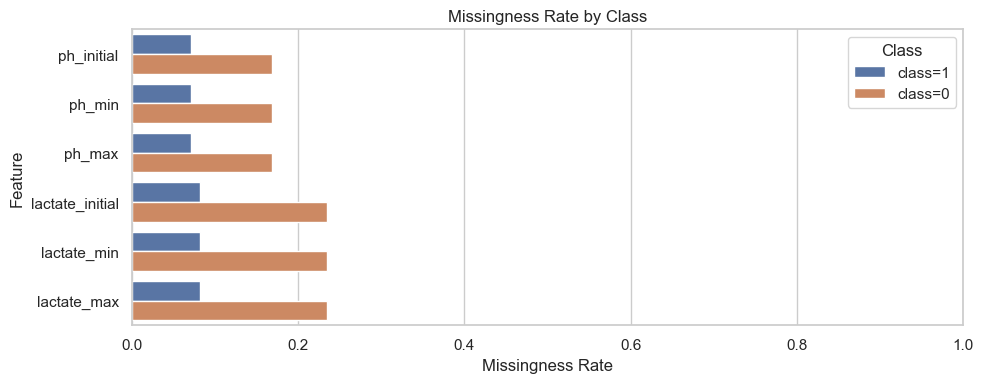

In [16]:
summary = create_missingness_summary_binary(df,)
plot_missingness_summary_binary(summary)


In [17]:
categorical_vars = ['gender', 'race', 'insurance']
for col in categorical_vars:
    if col in df.columns:
        print(f"\n{col}:\n", df[col].value_counts(dropna=False))


gender:
 gender
F    912
M    897
Name: count, dtype: int64

race:
 race
White       973
Black       505
Unknown      99
Hispanic     97
Other        77
Asian        58
Name: count, dtype: int64

insurance:
 insurance
Medicare    654
Private     568
Medicaid    490
Other        58
NaN          39
Name: count, dtype: int64


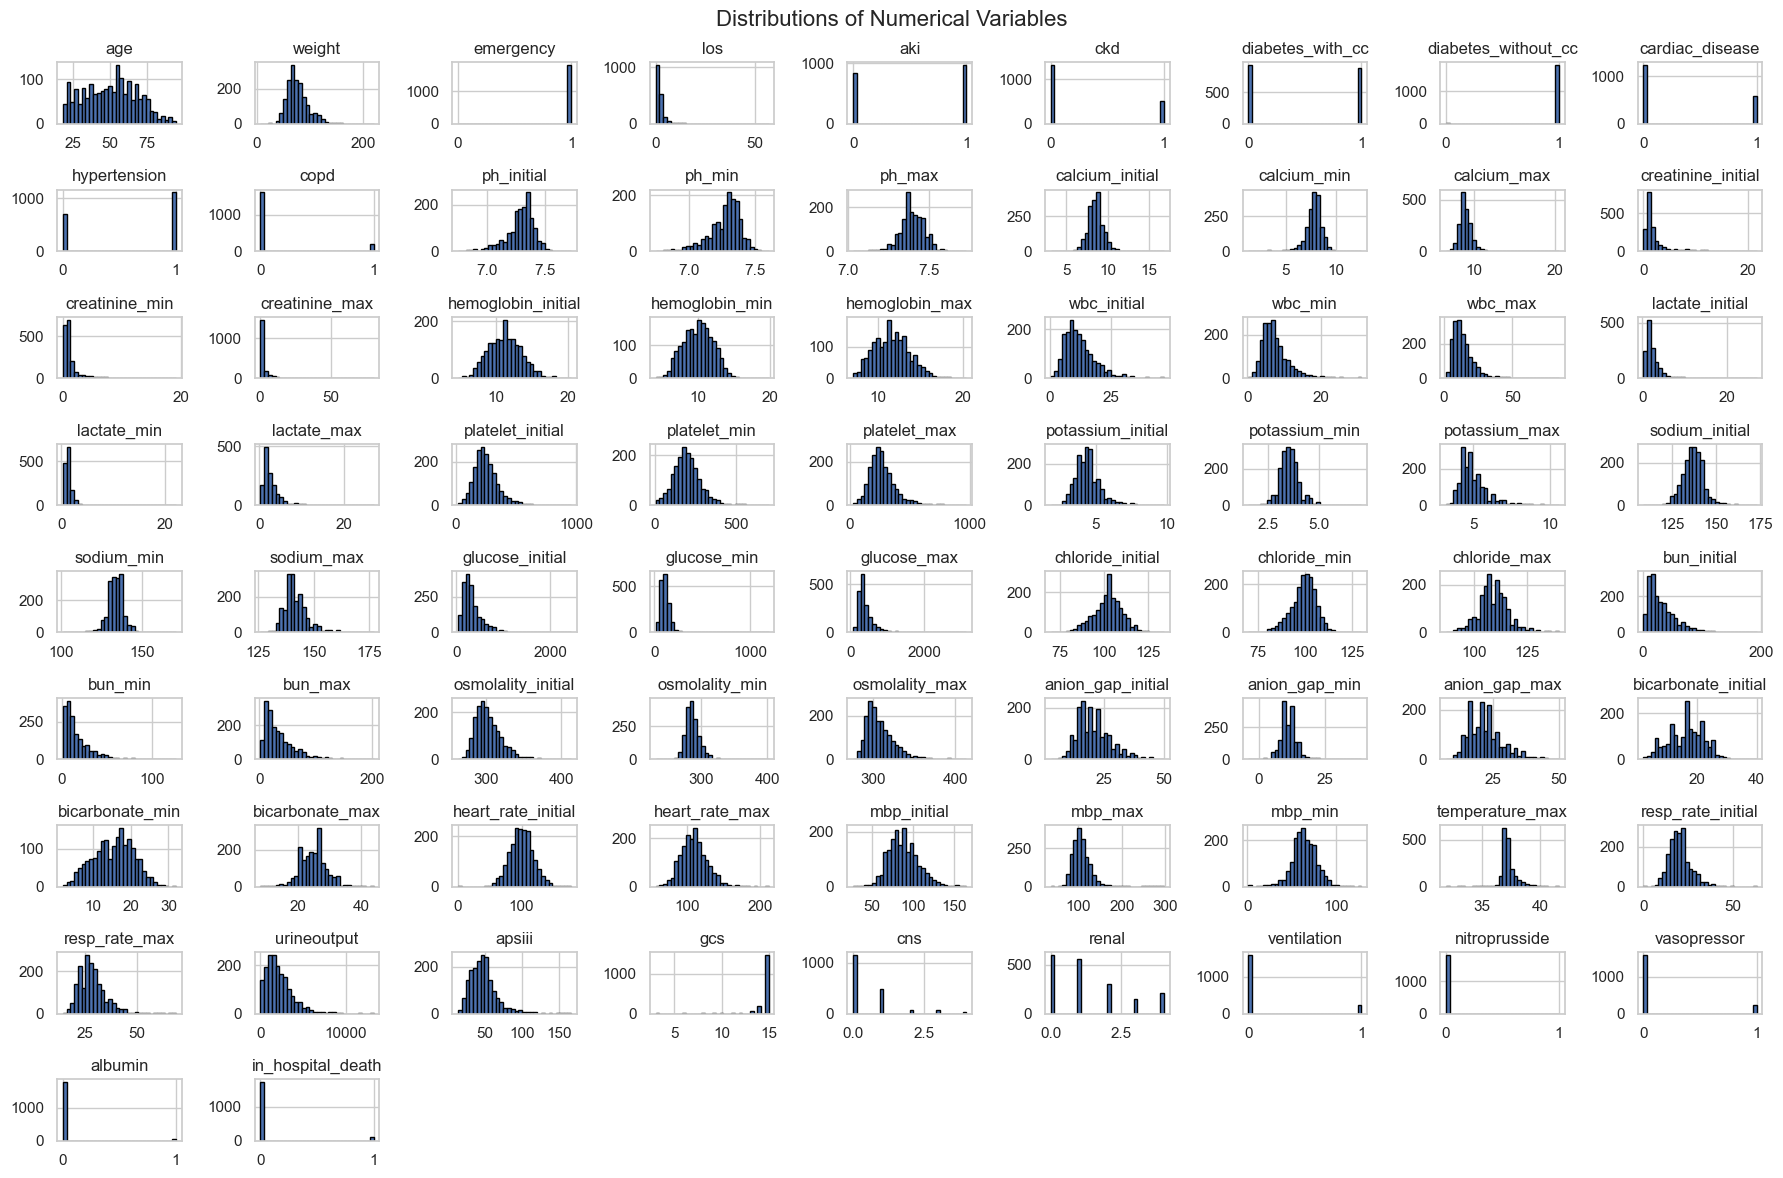

In [18]:
import matplotlib.pyplot as plt
# Histograms for numerical features
numeric_vars = df.select_dtypes(include='number').columns.tolist()
df[numeric_vars].hist(figsize=(18, 12), bins=30, edgecolor='black')
plt.suptitle("Distributions of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

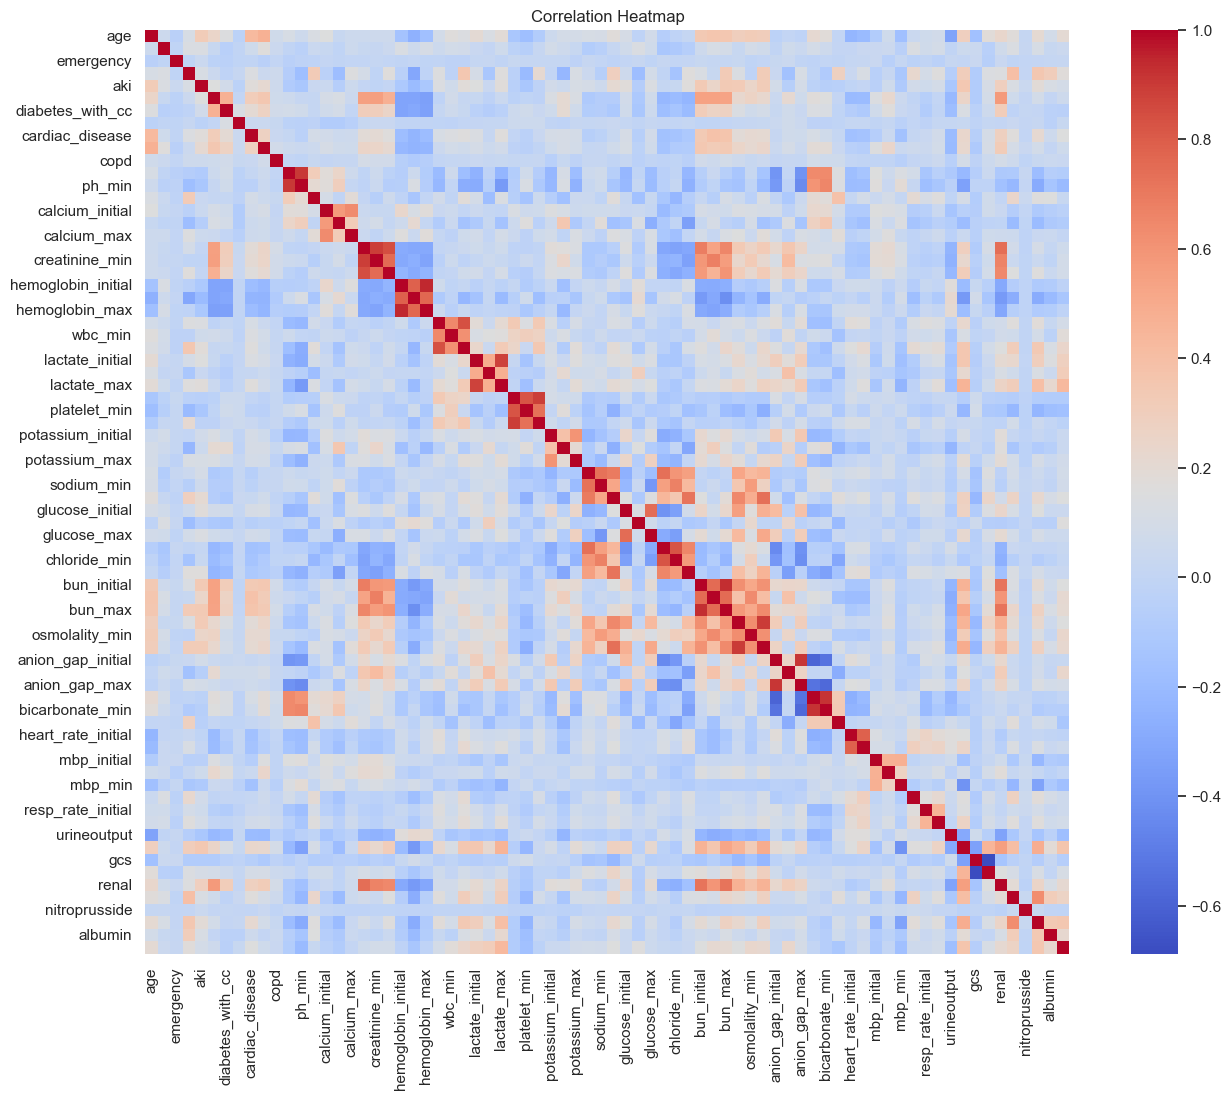

in_hospital_death    1.000000
lactate_max          0.428789
apsiii               0.362664
vasopressor          0.349550
lactate_min          0.313334
lactate_initial      0.282606
ventilation          0.264097
wbc_max              0.238764
osmolality_min       0.229618
anion_gap_min        0.228767
Name: in_hospital_death, dtype: float64


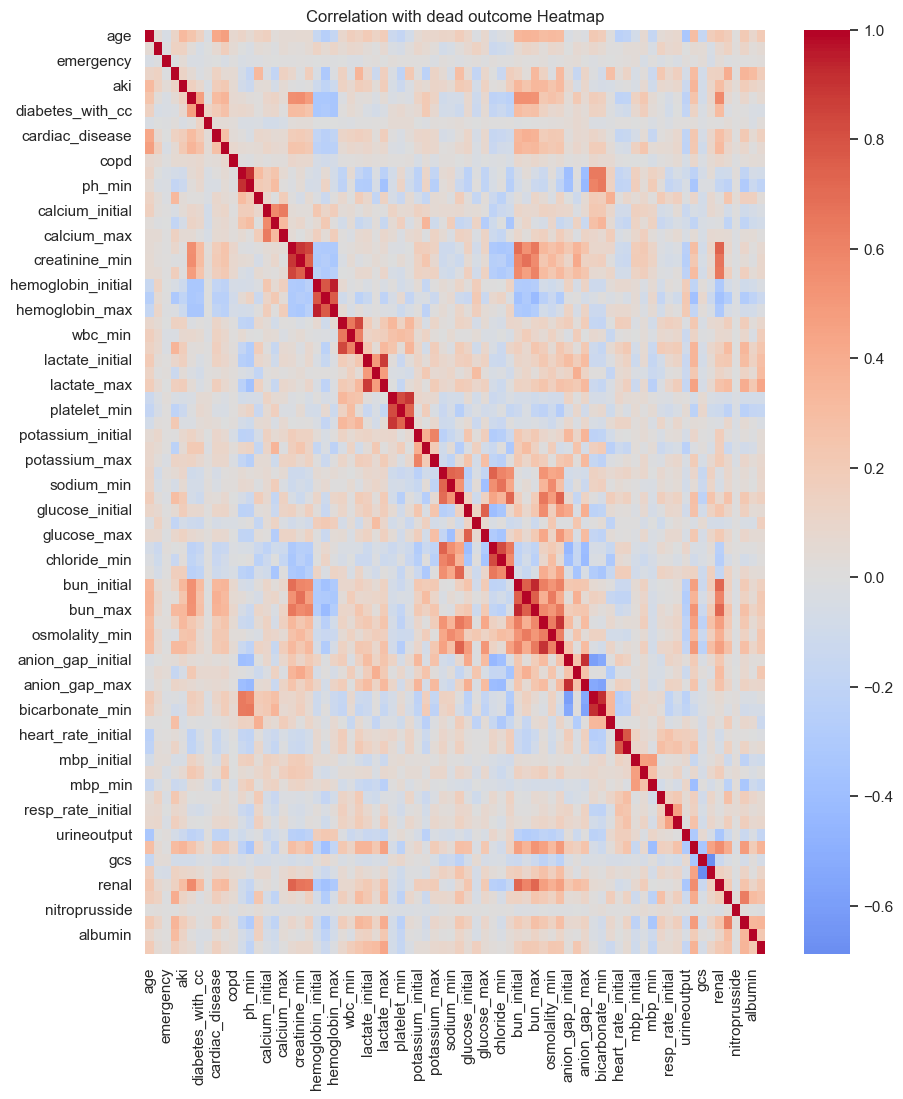

In [19]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_vars].corr(), cmap='coolwarm', annot=False, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

correlation = df.corr(numeric_only=True)['in_hospital_death'].sort_values(ascending=False)
print(correlation.head(10))
# 
plt.figure(figsize=(10, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation with dead outcome Heatmap')
plt.show()


## Exploratory Data Analysis


In [20]:
import numpy as np

### Distribution of age

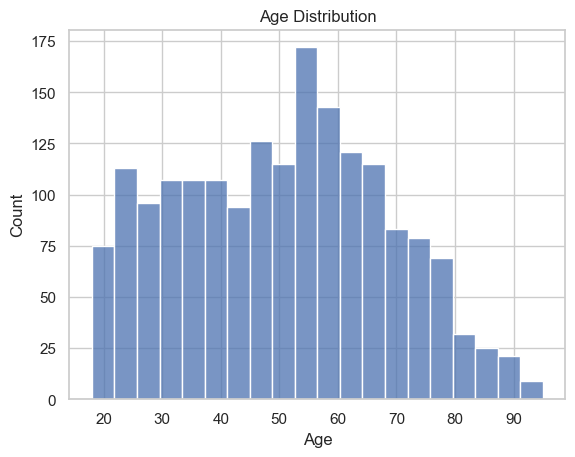

In [21]:
# sns.histplot(df.drop_duplicates(subset="subject_id")['age'].dropna().astype(int), bins=20)
sns.histplot(df['age'].dropna().astype(int).to_numpy(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

### Gender balance

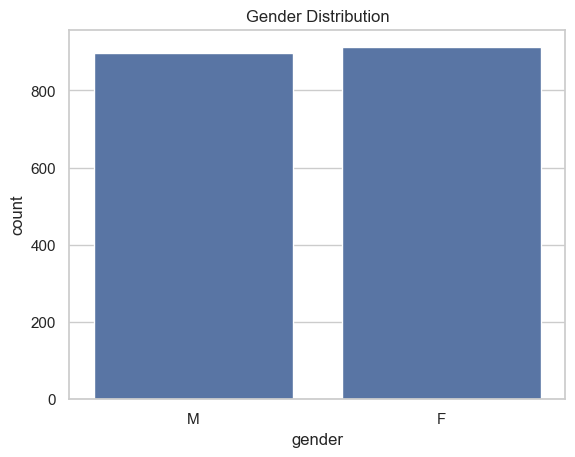

In [22]:
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()


### Distribution of the weight

Outlier the weight?

Maximum weight after filtering (<= 200): 195.0
Number of weights above 250: 0
Values above 200: [219.8]


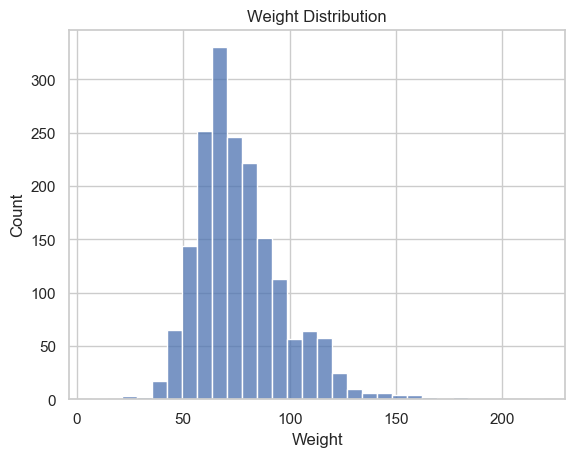

<Figure size 640x480 with 0 Axes>

In [23]:
weights = df['weight'].replace([np.inf, -np.inf], np.nan).dropna()

weights_less_200 = weights[weights <= 200].to_numpy()
weights_more_200 = weights[weights > 200].to_numpy()

max_weight = weights_less_200.max() if len(weights_less_200) > 0 else np.nan
print(f"Maximum weight after filtering (<= 200): {max_weight}")
print(f"Number of weights above 250: {(weights > 250).sum()}")
print(f"Values above 200: {weights_more_200}")

sns.histplot(df['weight'].dropna().astype(int).to_numpy(), bins=30)
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.show()

# sns.histplot(weights.to_numpy(), bins=100, ax=axs[0])
# axs[0].set_title("Weight Distribution (All Cleaned Values)")
# axs[0].set_xlabel("Weight")

# fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# sns.histplot(weights.to_numpy(), bins=100, ax=axs[0])
# axs[0].set_title("Weight Distribution (All Cleaned Values)")
# axs[0].set_xlabel("Weight")

# sns.histplot(weights_less_200, bins=10, ax=axs[1])
# axs[1].set_title("Weight Distribution (≤ 200)")
# axs[1].set_xlabel("Weight")

# sns.histplot(weights_more_200, bins=10, ax=axs[2])
# axs[2].set_title("Weight Distribution (> 200)")
# axs[2].set_xlabel("Weight")

plt.tight_layout()
plt.show()

### Insurance

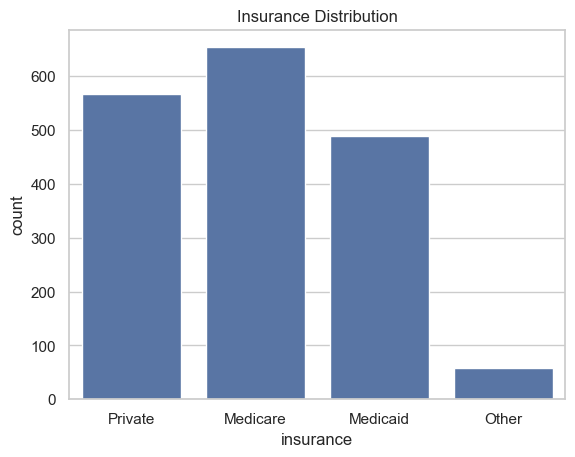

In [24]:
sns.countplot(data=df, x='insurance')
plt.title("Insurance Distribution")
plt.show()

### Emegency


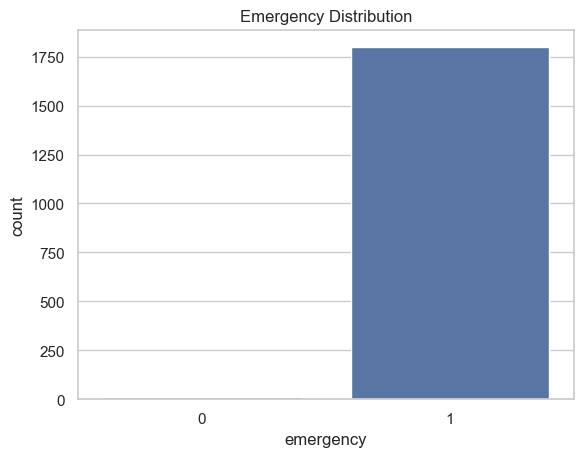

In [25]:
sns.countplot(data=df, x='emergency')
plt.title("Emergency Distribution")
plt.show()

### Deads
 In hspital death

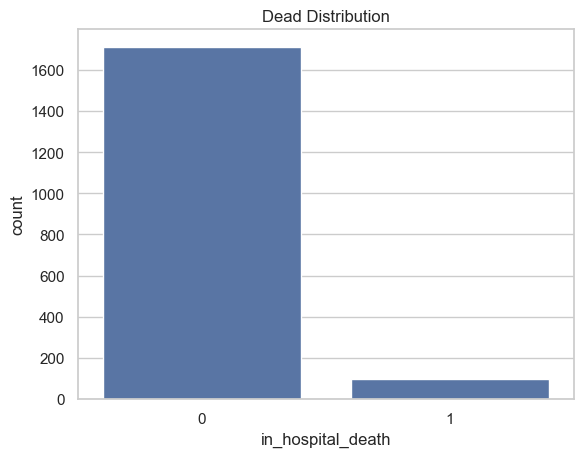

In [26]:
sns.countplot(data=df, x='in_hospital_death')
plt.title("Dead Distribution")
plt.show()

### Laboratory test

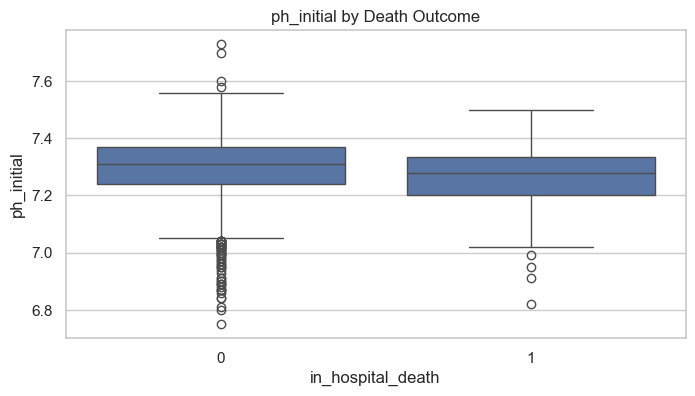

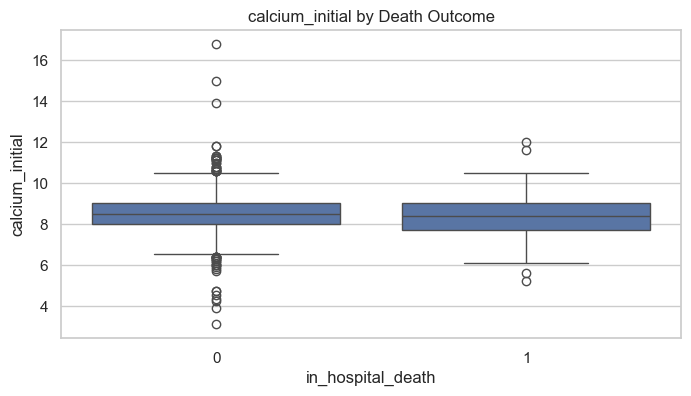

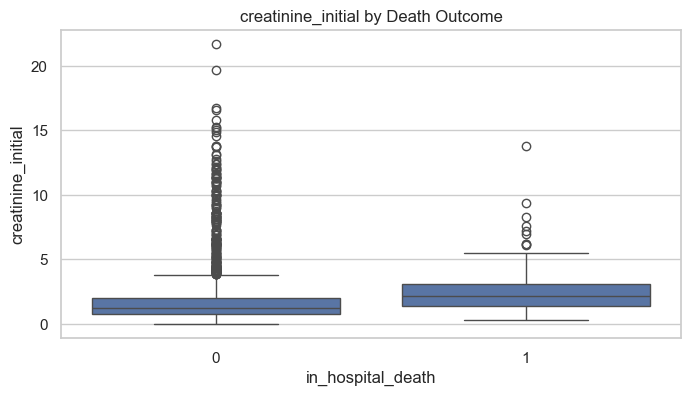

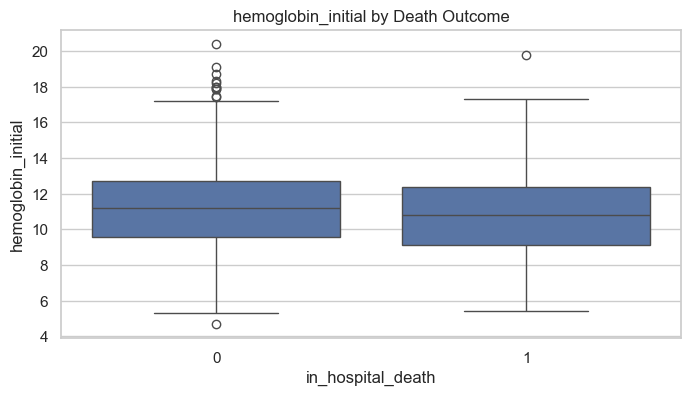

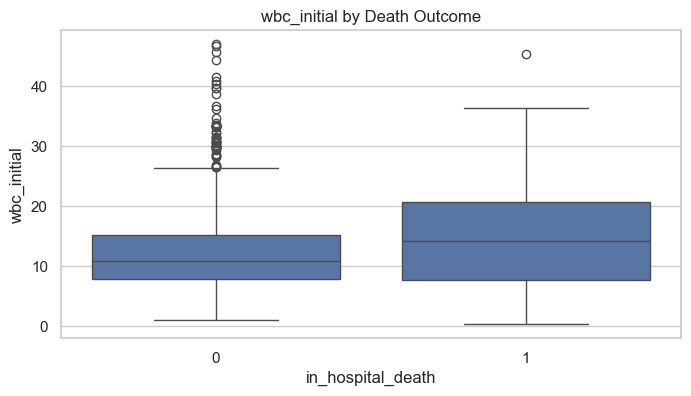

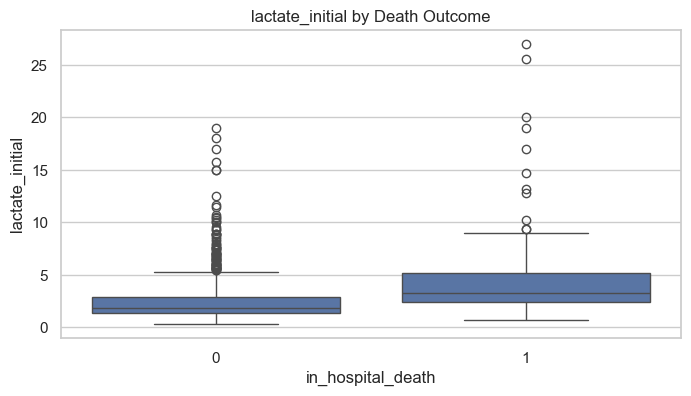

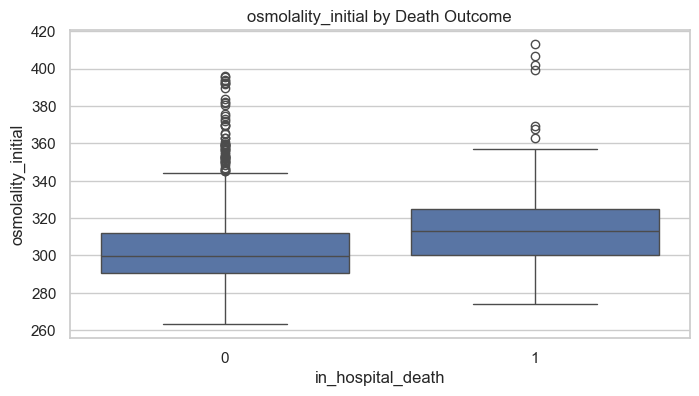

In [27]:
lab_features = [
    'ph_initial', 'calcium_initial', 'creatinine_initial',
    'hemoglobin_initial', 'wbc_initial', 'lactate_initial', 'osmolality_initial'
]

for feature in lab_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='in_hospital_death', y=feature)
    plt.title(f'{feature} by Death Outcome')
    plt.show()




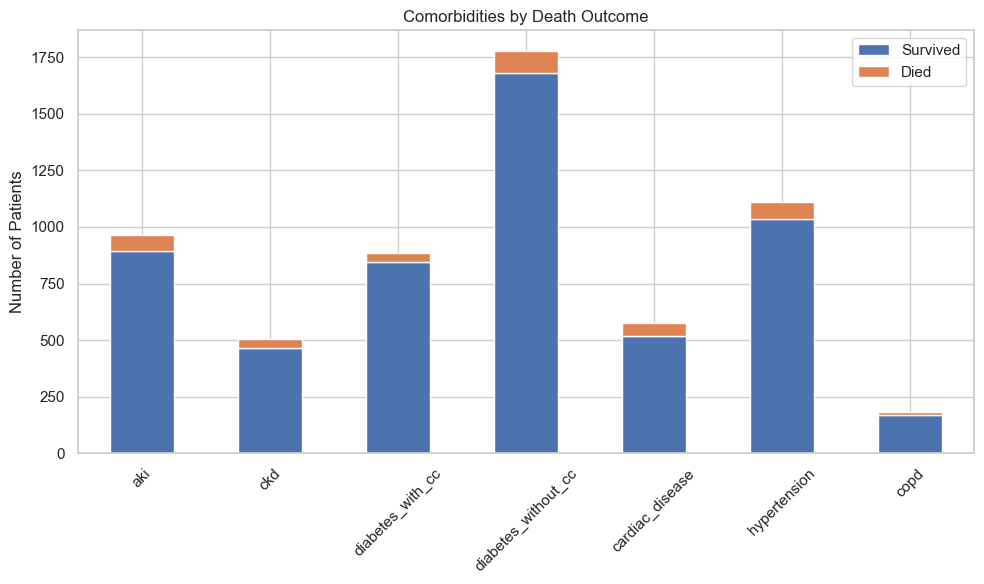

In [28]:
comorbidities = [
    'aki', 'ckd', 'diabetes_with_cc',
    'diabetes_without_cc', 'cardiac_disease', 'hypertension', 'copd'
]

comorbidity_counts = df.groupby('in_hospital_death')[comorbidities].sum().T
comorbidity_counts.columns = ['Survived', 'Died']
comorbidity_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Comorbidities by Death Outcome')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Characteristic at baseline between survivors and non-survivors group

In [43]:
!pip install tableone
!pip install --upgrade statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.6 MB 13.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 13.0 MB/s  0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.5
    Uninstalling statsmodels-0.14.5:
      Successfully uninstalled statsmodels-0.14.5



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import sys
!{sys.executable} -m pip install scipy
!pip install pandas==2.1.4


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest, kurtosistest
from tableone import TableOne

In [30]:
def get_nonnormal_columns(df, alpha=0.05):
    # Agostino and Anscombe tests
    # D’Agostino and Pearson Normality Test
    non_normal_cols = []
    for col in df.columns:
        data = df[col].dropna()
        if len(data) < 8:
            continue

        stat_nt, p_nt = normaltest(data)
        stat_kg, p_kg = kurtosistest(data)
        if p_nt < alpha or p_kg < alpha:
            non_normal_cols.append(col)
    return non_normal_cols

In [31]:
data = df.copy()
# Define labels and columns
column_labels = {
    'age': 'Age (year)',
    'gender': 'Male (%)',
    'race': 'White (%)',
    'heart_rate_initial': 'Heartrate (bpm)',
    'heart_rate_max': 'Heartrate_max (bpm)',
    'mbp_initial': 'MAP (mmHg)',
    'mbp_min': 'MAP_min (mmHg)',
    'resp_rate_initial': 'Respiratory_rate (insp/min)',
    'resp_rate_max': 'Respiratoryrate_max (insp/min)',
    'urineoutput': 'Urineoutput (ml)',
    'apsiii': 'APS III score',
    # 'sofa': 'SOFA score',
    'gcs': 'GCS score',
    'cns': 'CNS score',
    'renal': 'Renal score',
    'weight': 'Weight (kg)',
    'emergency': 'Admission, emergency (%)',
    'ventilation': 'Ventilation (%)',
    'nitroprusside': 'Nitrate pune (%)',
    'vasopressor': 'Vasopressor (%)',
    'albumin': 'Albumin (%)',
    'aki': 'AKI (%)',
    'ckd': 'CKD (%)',
    'cardiac_disease': 'Cardiac disease (%)',
    'hypertension': 'Hypertension (%)',
    'copd': 'COPD (%)',
    'lactate_max': 'Lactate_max (mmol/L)',
    'creatinine_initial': 'Scr (mg/dL)',
    'creatinine_max': 'Scr_max (mg/dL)',
    'ph_initial': 'PH',
    'ph_min': 'PH_min',
    'glucose_initial': 'Glucose (mg/dL)',
    'glucose_max': 'Glucose_max (mg/dL)',
    'sodium_initial': 'Sodium (mEq/L)',
    'sodium_max': 'Sodium_max (mEq/L)',
    'potassium_initial': 'Potassium (mEq/L)',
    'potassium_max': 'Potassium_max (mEq/L)',
    'calcium_initial': 'Calcium (mg/dL)',
    'chloride_initial': 'Chloride (mEq/L)',
    'wbc_initial': 'WBC (K/uL)',
    'wbc_max': 'WBC_max (K/uL)',
    'platelet_initial': 'PLT (K/uL)',
    'platelet_min': 'PLT_min (K/uL)',
    'bun_max': 'BUN_max (mg/dL)',
    'osmolality_initial': 'osmolarity',
    'osmolality_max': 'osmolarity_max',
    'osmolality_min': 'osmolarity_min'
}

columns = list(column_labels.keys())

categorical = [
    'gender', 'race', 'emergency', 'ventilation', 'nitroprusside', 'vasopressor',
    'albumin', 'aki', 'ckd', 'cardiac_disease', 'hypertension', 'copd'
]
continuous = [col for col in columns if col not in categorical]


labels = {var: {1: column_labels[var]} for var in categorical}
# print(labels)

# Custom labels
survivors_n = len(data[data['in_hospital_death'] == 0])
nonsurvivors_n = len(data[data['in_hospital_death'] == 1])
data['in_hospital_death_label'] = data['in_hospital_death'].map({
    0: f'Survivors (n={survivors_n})',
    1: f'_Nonsurvivors (n={nonsurvivors_n})'    
})

limit={
    'gender':1,
    'race':1
}

nonnormal = get_nonnormal_columns(data[continuous])
# Remove age to simulate the paper table
nonnormal.remove('age')

# Create TableOne
table = TableOne(
    data,
    columns=columns,
    categorical=categorical,
    labels=labels,
    groupby='in_hospital_death_label',
    pval=True,
    rename=column_labels,
    label_suffix=False,
    missing=False,
    limit=limit,
    decimals=2,
    nonnormal=nonnormal
)

# Print TableOne
print(table.tabulate(tablefmt="github"))


|                                |       | Overall                   | Survivors (n=1711)        | _Nonsurvivors (n=98)    | P-Value   |
|--------------------------------|-------|---------------------------|---------------------------|-------------------------|-----------|
| n                              |       | 1809                      | 1711                      | 98                      |           |
| Age (year)                     |       | 50.46 (17.91)             | 49.60 (17.64)             | 65.45 (16.03)           | <0.001    |
| Male (%)                       | F     | 912 (50.41)               | 867 (50.67)               | 45 (45.92)              | 0.417     |
| White (%)                      | White | 973 (53.79)               | 930 (54.35)               | 43 (43.88)              | <0.001    |
| Heartrate (bpm)                |       | 99.00 [88.00,111.00]      | 99.00 [88.00,111.00]      | 95.50 [83.25,111.50]    | 0.235     |
| Heartrate_max (bpm)            |       

In [ ]:
table.to_csv('table.csv')

In [32]:
latex_str = table.tabulate(tablefmt="latex")

with open("tableone_output.tex", "w") as f:
    f.write(latex_str)

print("✅ LaTeX table saved to 'tableone_output.tex'")

✅ LaTeX table saved to 'tableone_output.tex'


## MICE Imputation
ph_* and lactate_* > 28% of missing values; urineoutput and calcium_* ~ 4%; weight ~ 2%; insurance ~1%; hemoglobin_*, platelet_*, wbc_*, osmolality_*, glucose_*, chloride_*, potassium_*, sodium_*, bun_*, creatinine_*, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension < 1%

Features to impute with MICE:
ph, lactate, urineoutput, calcium, weight, hemoglobin, platelet, wbc, osmolality, glucose, chloride, potassium, sodium, bun, creatinine, cns, gcs, resp_rate_max, mbp_max, renal, heart_rate_max, initial_mbp, initial_resp_rate, initial_heart_rate, cardiac_disease, ckd, aki, copd, hypertension.
Not MICE:
Insurance